<a href="https://colab.research.google.com/github/eliasdengo/Python-practice-from-beginning-to-advance/blob/Eliasrepos/loan_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
#importing the dependence
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import joblib

data collection and processing

In [76]:
#data loading to pandas
loan_data=pd.read_csv('/content/sample_data/loan_data.csv')

In [77]:
type(loan_data)

pandas.core.frame.DataFrame

In [78]:
#get top 5 sample data
loan_data.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [79]:
#row and column of data set
loan_data.shape

(381, 13)

In [80]:
#statistics of loan data
loan_data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,381.000000,381.000000,381.000000,370.000000,351.000000
mean,3579.845144,1277.275381,104.986877,340.864865,0.837607
std,1419.813818,2340.818114,28.358464,68.549257,0.369338
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2600.000000,0.000000,90.000000,360.000000,1.000000
50%,3333.000000,983.000000,110.000000,360.000000,1.000000
75%,4288.000000,2016.000000,127.000000,360.000000,1.000000
max,9703.000000,33837.000000,150.000000,480.000000,1.000000


In [81]:
#number of missing value in column
loan_data.isnull().sum()

,0
Loan_ID,0
Gender,5
Married,0
Dependents,8
Education,0
Self_Employed,21
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,11


In [82]:
#droping missing value
loan_data=loan_data.dropna()

In [83]:
#check missing value
loan_data.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [84]:
#label encoding
loan_data.replace({"Loan_Status":{"N":0,"Y":1}},inplace=True)

/tmp/ipython-input-84-420731442.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_data.replace({"Loan_Status":{"N":0,"Y":1}},inplace=True)


In [85]:
# loan data head which is top 5
loan_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,1


In [86]:
#number of row and column
loan_data.shape

(308, 13)

In [87]:
#loan data dependent
loan_data['Dependents'].value_counts()

,count
Dependents,
0,194
2,47
1,43
3+,24


In [88]:
#replace the value of 3+ to 4
loan_data=loan_data.replace(to_replace='3+',value=4)

In [58]:
#loan data Dependents
loan_data['Dependents'].value_counts()

,count
Dependents,
0,194
2,47
1,43
4,24


Data Visualization

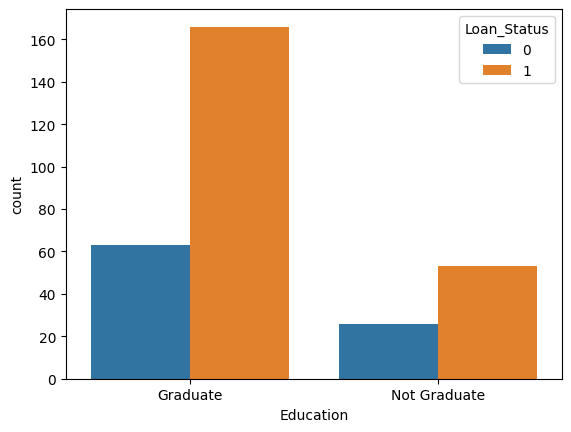

In [89]:
#Education and Loan status
sns.countplot(x="Education", hue="Loan_Status", data=loan_data)
plt.show()



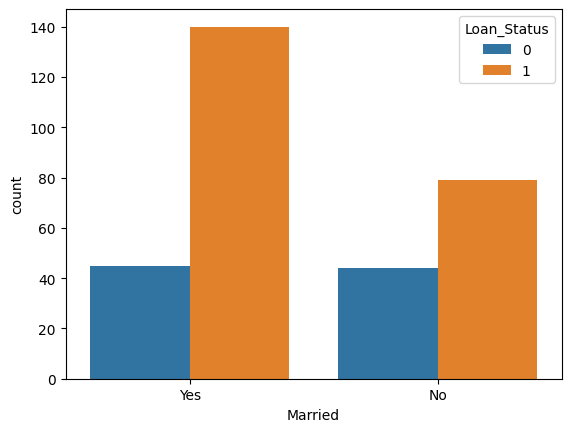

In [90]:
#Married status	 and Loan status
sns.countplot(x="Married", hue="Loan_Status", data=loan_data)
plt.show()

In [91]:

#converting to numerical value
loan_data.replace({"Married":{"No":0,"Yes":1},"Gender":{"Male":1,"Female":0},"Education":{"Graduate":1,"Not Graduate":0},"Self_Employed":{"Yes":1,"No":0},"Property_Area":{"Rural":0,"Semiurban":1,"Urban":2}},inplace=True)


/tmp/ipython-input-91-2953192991.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_data.replace({"Married":{"No":0,"Yes":1},"Gender":{"Male":1,"Female":0},"Education":{"Graduate":1,"Not Graduate":0},"Self_Employed":{"Yes":1,"No":0},"Property_Area":{"Rural":0,"Semiurban":1,"Urban":2}},inplace=True)


In [92]:
#separating data and label
x=loan_data.drop(columns=['Loan_ID','Loan_Status'],axis=1)
y=loan_data['Loan_Status']

In [93]:
print(x)
print(y)

     Gender  Married Dependents  Education  Self_Employed  ApplicantIncome  \
0         1        1          1          1              0             4583   
1         1        1          0          1              1             3000   
2         1        1          0          0              0             2583   
3         1        0          0          1              0             6000   
4         1        1          0          0              0             2333   
..      ...      ...        ...        ...            ...              ...   
376       1        1          4          1              0             5703   
377       1        1          0          1              0             3232   
378       0        0          0          1              0             2900   
379       1        1          4          1              0             4106   
380       0        0          0          1              1             4583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_Hi

In [94]:

#train and test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,stratify=y,random_state=2)

In [95]:
print(x.shape,x_train.shape,x_test.shape)

(308, 11) (277, 11) (31, 11)


Training model   support vector machine model

In [97]:
classifier=svm.SVC(kernel='linear')

In [98]:
#train support vector machine model
classifier.fit(x_train,y_train)

SVC(kernel='linear')

Model Evaluation

In [99]:
# x_train model evaluation
x_train_prediction=classifier.predict(x_train)
x_train_accuracy=accuracy_score(x_train_prediction,y_train)

In [101]:
print('x_training_model_accuracy:',x_train_accuracy)

x_training_model_accuracy: 0.8267148014440433


In [102]:
# x_test model evaluation
x_test_prediction=classifier.predict(x_test)
x_test_accuracy=accuracy_score(x_test_prediction,y_test)

In [103]:
print('x_test_model_accuracy:',x_test_accuracy)

x_test_model_accuracy: 0.8064516129032258


save trained Model

In [104]:
# Save the model
joblib.dump(classifier, 'loan_model.pkl')

# Load the model
loaded_model = joblib.load('loan_model.pkl')

Making prediction system

In [105]:
def predict_loan_status(applicant_data):
    # Ensure applicant_data is in the correct format
    applicant_data = pd.DataFrame([applicant_data])

    # Make predictions
    prediction = loaded_model.predict(applicant_data)

    if prediction[0]=='Y':
        return "Loan Approved"
    else:
        return "Loan Not Approved"


def get_user_input():
    print("Enter the details for loan prediction:")
    gender = int(input("Gender (1 for Male, 0 for Female): "))
    married = int(input("Married (1 for Yes, 0 for No): "))
    dependents = int(input("Dependents (0, 1, 2, or 4 for 3+): "))
    education = int(input("Education (1 for Graduate, 0 for Not Graduate): "))
    self_employed = int(input("Self Employed (1 for Yes, 0 for No): "))
    applicant_income = float(input("Applicant Income: "))
    coapplicant_income = float(input("Coapplicant Income: "))
    loan_amount = float(input("Loan Amount: "))
    loan_amount_term = int(input("Loan Amount Term (in months): "))
    credit_history = int(input("Credit History (1 for Yes, 0 for No): "))
    property_area = int(input("Property Area (0 for Rural, 1 for Semiurban, 2 for Urban): "))

    return {
        'Gender': gender,
        'Married': married,
        'Dependents': dependents,
        'Education': education,
        'Self_Employed': self_employed,
        'ApplicantIncome': applicant_income,
        'CoapplicantIncome': coapplicant_income,
        'LoanAmount': loan_amount,
        'Loan_Amount_Term': loan_amount_term,
        'Credit_History': credit_history,
        'Property_Area': property_area
    }

# Get user input
new_applicant = get_user_input()

# Make a prediction
loan_status = predict_loan_status(new_applicant)
print(f"The predicted loan status is: {loan_status}")


Enter the details for loan prediction:
Gender (1 for Male, 0 for Female): 1
Married (1 for Yes, 0 for No): 1
Dependents (0, 1, 2, or 4 for 3+): 0
Education (1 for Graduate, 0 for Not Graduate): 1
Self Employed (1 for Yes, 0 for No): 1
Applicant Income: 400
Coapplicant Income: 400
Loan Amount: 8000
Loan Amount Term (in months): 36
Credit History (1 for Yes, 0 for No): 1
Property Area (0 for Rural, 1 for Semiurban, 2 for Urban): 2
The predicted loan status is: Loan Not Approved
